# Использование локальной VLLM для задачи OCR

Модели разрешено брать с https://huggingface.co, при этом для меня задача усложняется тем, что я выполняю работу на mac-е, а большая часть моделей там заточена под CUDA.

Тем не менее, mlx-community предоставляет модели специально под mac.

## Предобработка изображений

Изображения в выборке тяжелые, в чистом виде нужна ооочень умная моделька, чтобы с ними справляться.

Можем существенно облегчить задачу модели предобработкой

In [2]:
image_paths = [
    "pictures_iad/IMG_2694.jpg",
    "pictures_iad/IMG_2695.jpg",
    "pictures_iad/IMG_2696.jpg",
    "pictures_iad/IMG_2697.jpg",
    "pictures_iad/IMG_99998.jpg",
    "pictures_iad/IMG_99999.jpg",
]

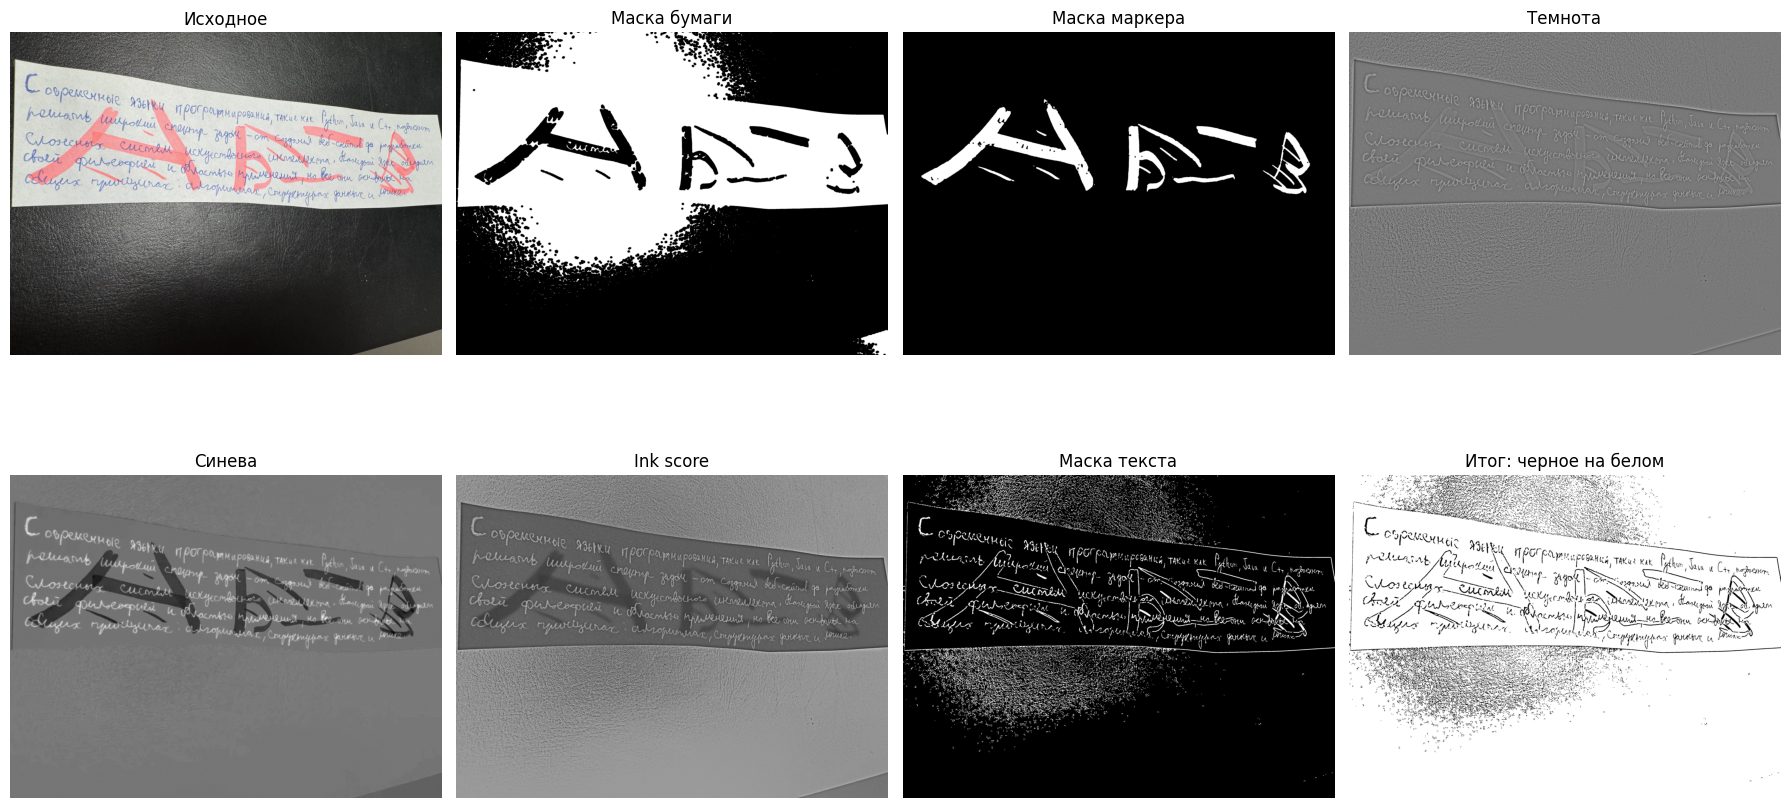

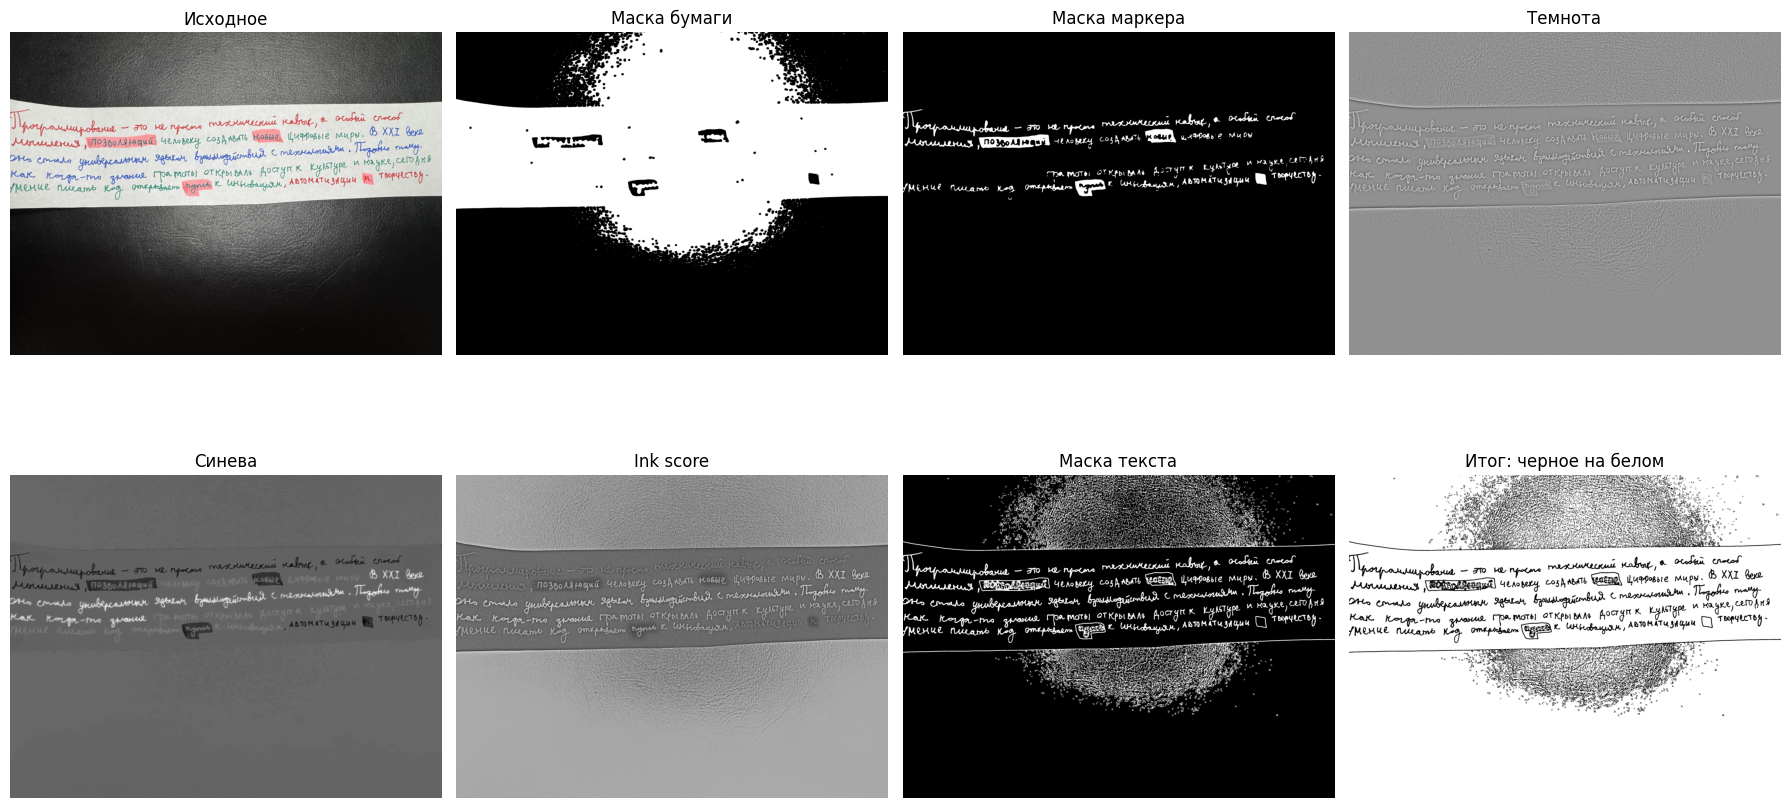

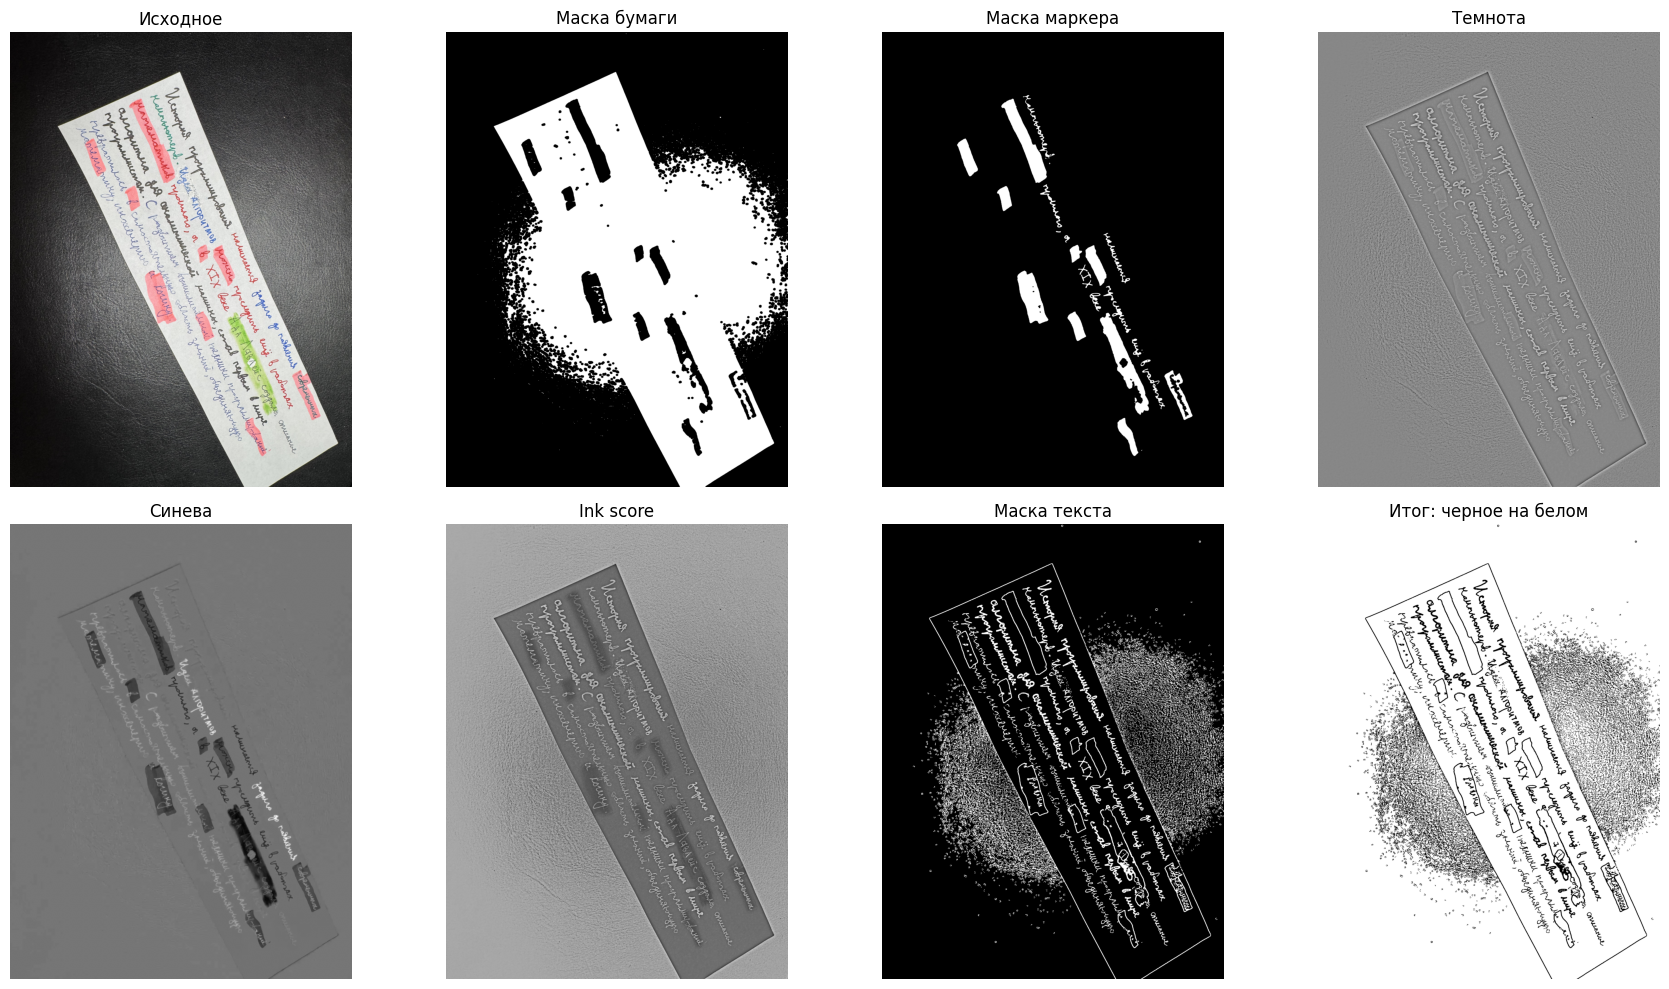

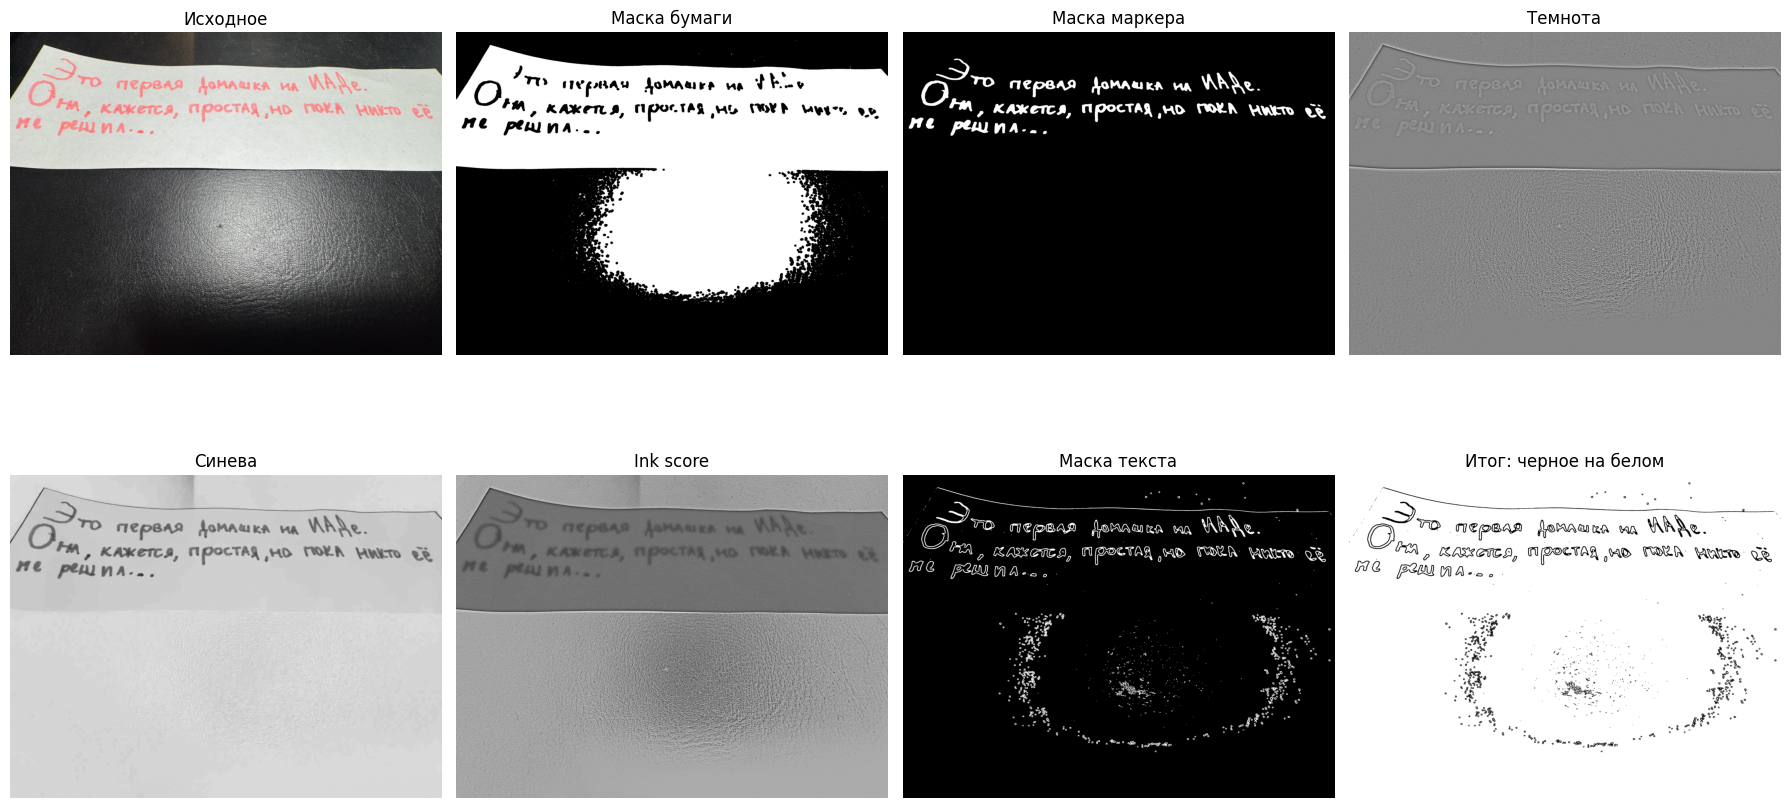

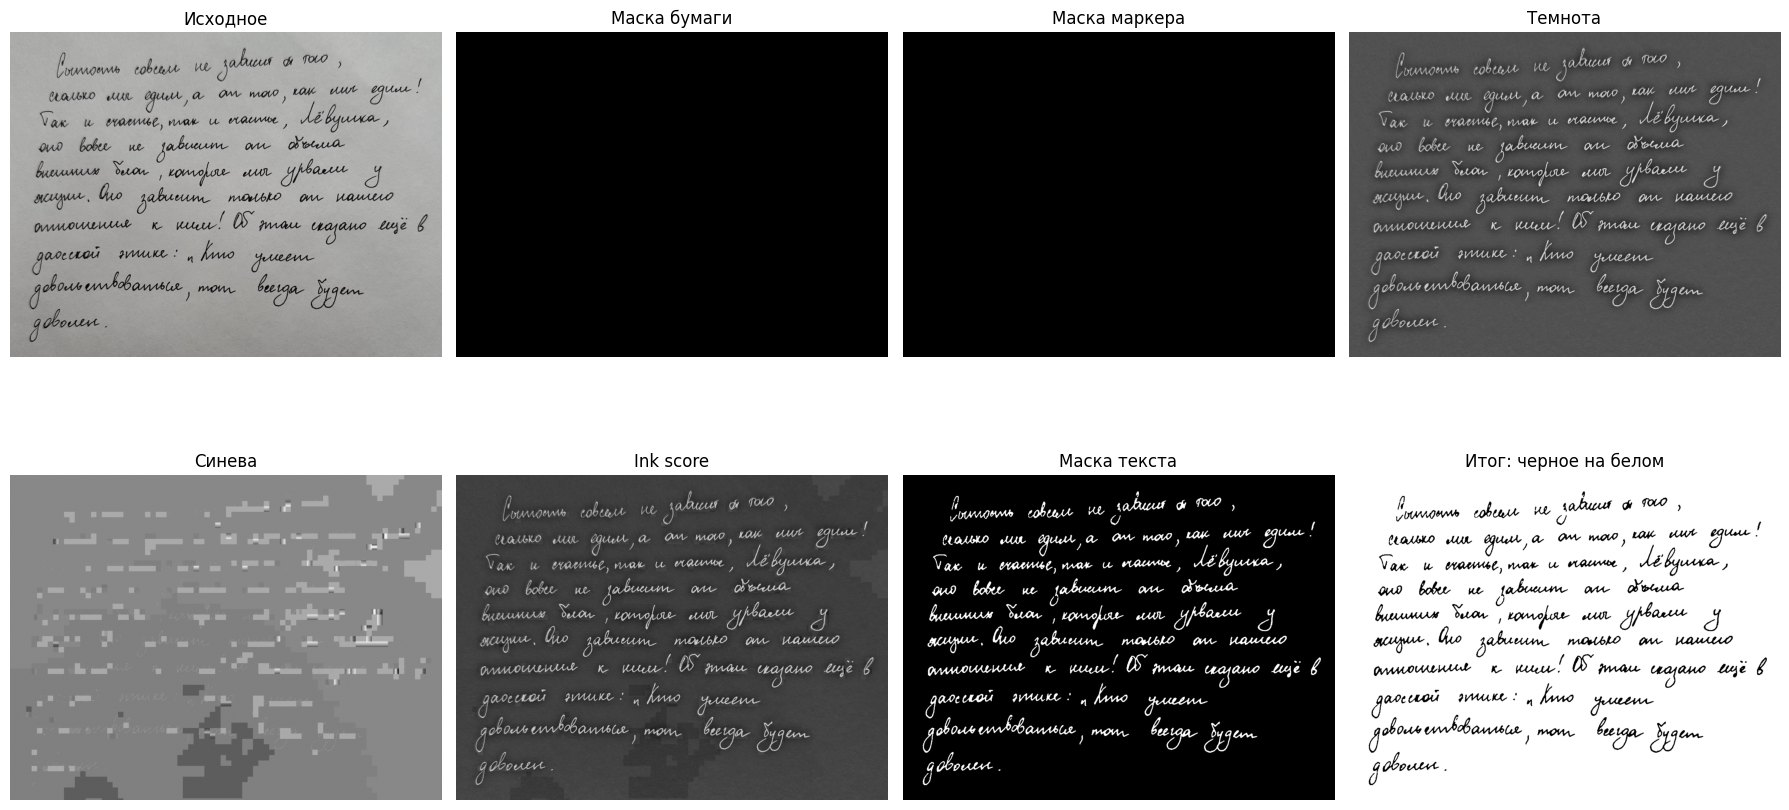

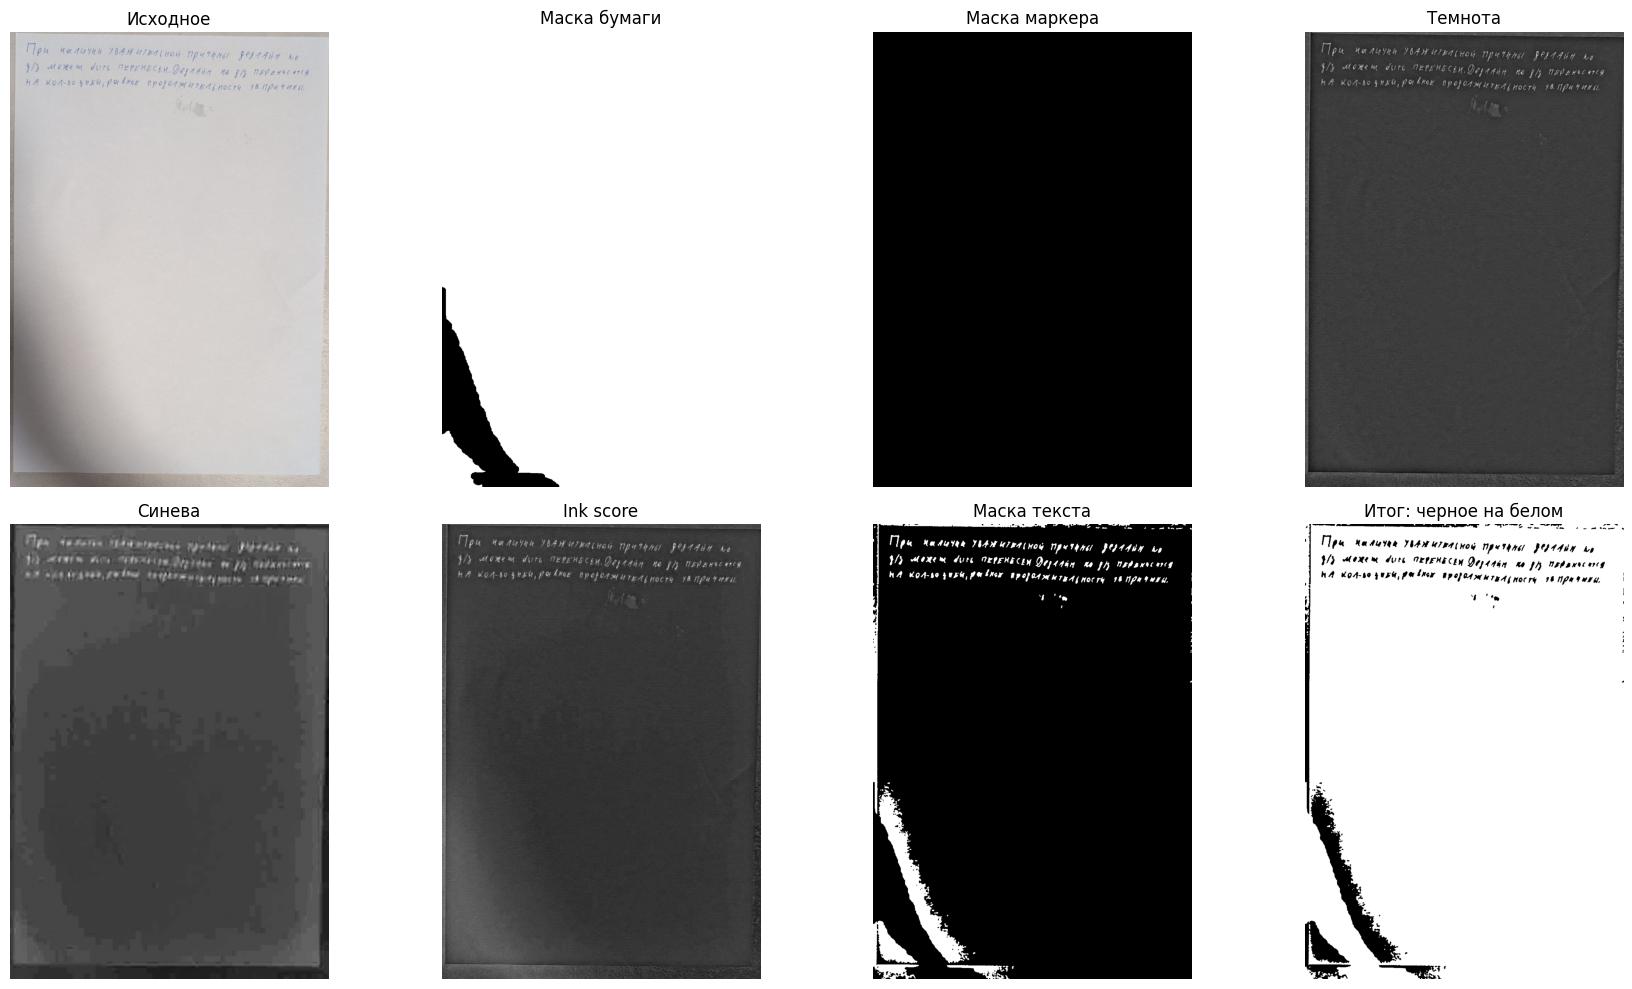

['pictures_iad_preprocessed/IMG_2694_bw.png',
 'pictures_iad_preprocessed/IMG_2695_bw.png',
 'pictures_iad_preprocessed/IMG_2696_bw.png',
 'pictures_iad_preprocessed/IMG_2697_bw.png',
 'pictures_iad_preprocessed/IMG_99998_bw.png',
 'pictures_iad_preprocessed/IMG_99999_bw.png']

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _normalize01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mn, mx = x.min(), x.max()
    if mx - mn < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)


def _remove_small_components(mask: np.ndarray, min_area: int) -> np.ndarray:
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            out[labels == label] = 255
    return out


def _remove_large_components(mask: np.ndarray, max_area: int) -> np.ndarray:
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area <= max_area:
            out[labels == label] = 255
    return out


def preprocess_text_mask(
        image_bgr: np.ndarray,
        marker_s_thresh: int = 70,
        marker_v_thresh: int = 70,
        min_component_area: int = 12,
        max_component_fraction: float = 0.08,
        debug: bool = False,
):
    """
    Цветовой пайплайн без геометрии.
    Цель: получить бинарную картинку "черные буквы на белом фоне".

    Идея:
      1) найти вероятную бумагу;
      2) найти яркий маркер по HSV;
      3) оценить "чернильность" как комбинацию темноты, синевы и локального контраста;
      4) внутри маркера не удалять всё, а искать тонкие тёмные штрихи мягче;
      5) очистить маску компонентами.
    """
    h, w = image_bgr.shape[:2]
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

    b = image_bgr[:, :, 0].astype(np.float32)
    g = image_bgr[:, :, 1].astype(np.float32)
    r = image_bgr[:, :, 2].astype(np.float32)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    L = lab[:, :, 0].astype(np.float32)
    A = lab[:, :, 1].astype(np.float32)
    B = lab[:, :, 2].astype(np.float32)

    # --- 1. Маска вероятной бумаги ---
    # Бумага: светлая, малонасыщенная, каналы близки друг к другу.
    rgb_spread = np.max(image_bgr, axis=2).astype(np.float32) - np.min(image_bgr, axis=2).astype(np.float32)
    paper_mask = (
                         (V > 125) &
                         (S < 80) &
                         (rgb_spread < 70)
                 ).astype(np.uint8) * 255
    paper_mask = cv2.medianBlur(paper_mask, 5)
    paper_mask = cv2.morphologyEx(
        paper_mask,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)),
        iterations=2,
    )

    # --- 2. Маска маркера ---
    # Розовый/красный + зелёный. Hue в OpenCV: [0, 179].
    pink1 = ((H <= 12) | (H >= 165)) & (S >= marker_s_thresh) & (V >= marker_v_thresh)
    pink2 = ((H >= 145) & (H <= 179)) & (S >= marker_s_thresh) & (V >= marker_v_thresh)
    green = ((H >= 35) & (H <= 95)) & (S >= marker_s_thresh) & (V >= marker_v_thresh)
    marker_mask = (pink1 | pink2 | green).astype(np.uint8) * 255
    marker_mask = cv2.medianBlur(marker_mask, 5)
    marker_mask = cv2.morphologyEx(
        marker_mask,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)),
        iterations=1,
    )

    # --- 3. Оценка темноты и локального контраста ---
    # Локальная белая подложка: большой blur по яркости.
    local_bg = cv2.GaussianBlur(L, (0, 0), sigmaX=13, sigmaY=13)
    darkness = _normalize01(local_bg - L)  # тёмные объекты на светлом фоне

    # Синева полезна для синей ручки.
    blueness = _normalize01(b - 0.5 * (r + g))

    # "Нечисто-белость" для тёмных/чернильных пикселей.
    nonwhite = _normalize01(255.0 - V.astype(np.float32))

    # Комбинированный score вне маркера.
    ink_score = 0.55 * darkness + 0.25 * blueness + 0.20 * nonwhite

    # Внутри маркера цвет искажен, поэтому сильнее полагаемся на темноту и локальный контраст.
    ink_under_marker_score = 0.80 * darkness + 0.20 * nonwhite

    # Бумага помогает отсечь стол, но позволяем небольшое расширение вокруг неё.
    paper_dilated = cv2.dilate(
        paper_mask,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)),
        iterations=1,
    )

    # --- 4. Порогование ---
    # Два разных правила: вне маркера и внутри маркера.
    #base_text = (ink_score > 0.45)
    #text_under_marker = ((marker_mask > 0) & (ink_under_marker_score > 0.4))

    paper_region = paper_dilated > 0
    if np.count_nonzero(paper_region) < 100:
        paper_region = np.ones_like(ink_score, dtype=bool)

    vals = ink_score[paper_region]
    thr_base = np.percentile(vals, 94)
    thr_base = np.clip(thr_base, 0.22, 0.55)
    base_text = ink_score > thr_base

    marker_region = marker_mask > 0
    if np.count_nonzero(marker_region) > 20:
        marker_vals = ink_under_marker_score[marker_region]
        thr_marker = np.percentile(marker_vals, 86)
        thr_marker = np.clip(thr_marker, 0.12, 0.40)
    else:
        thr_marker = 0.22

    text_under_marker = marker_region & (ink_under_marker_score > thr_marker)


    candidate_text = ((base_text | text_under_marker) & (paper_dilated > 0)).astype(np.uint8) * 255

    # Дополнительное подавление самих заливок маркером:
    # если участок маркера не выглядит достаточно тёмным, убираем его.
    weak_marker_fill = ((marker_mask > 0) & (ink_under_marker_score < 0.18))
    candidate_text[weak_marker_fill] = 0

    # --- 5. Морфологическая очистка ---
    candidate_text = cv2.morphologyEx(
        candidate_text,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
        iterations=1,
    )
    candidate_text = cv2.morphologyEx(
        candidate_text,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
        iterations=1,
    )

    candidate_text = _remove_small_components(candidate_text, min_area=min_component_area)
    max_component_area = int(max_component_fraction * h * w)
    candidate_text = _remove_large_components(candidate_text, max_area=max_component_area)

    # Финальная лёгкая стыковка штрихов.
    candidate_text = cv2.morphologyEx(
        candidate_text,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)),
        iterations=1,
    )

    # Итог: чёрный текст на белом фоне.
    final_bw = np.full((h, w), 255, dtype=np.uint8)
    final_bw[candidate_text > 0] = 0

    debug_data = {
        "rgb": img_rgb,
        "paper_mask": paper_mask,
        "marker_mask": marker_mask,
        "darkness": darkness,
        "blueness": blueness,
        "nonwhite": nonwhite,
        "ink_score": ink_score,
        "ink_under_marker_score": ink_under_marker_score,
        "candidate_text": candidate_text,
        "final_bw": final_bw,
    }

    if debug:
        return final_bw, debug_data
    return final_bw


def show_preprocessing(path: str, figsize=(18, 10)):
    image_bgr = cv2.imread(path)
    if image_bgr is None:
        raise FileNotFoundError(path)

    final_bw, dbg = preprocess_text_mask(image_bgr, debug=True)

    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.ravel()

    axes[0].imshow(dbg["rgb"])
    axes[0].set_title("Исходное")
    axes[0].axis("off")

    axes[1].imshow(dbg["paper_mask"], cmap="gray")
    axes[1].set_title("Маска бумаги")
    axes[1].axis("off")

    axes[2].imshow(dbg["marker_mask"], cmap="gray")
    axes[2].set_title("Маска маркера")
    axes[2].axis("off")

    axes[3].imshow(dbg["darkness"], cmap="gray")
    axes[3].set_title("Темнота")
    axes[3].axis("off")

    axes[4].imshow(dbg["blueness"], cmap="gray")
    axes[4].set_title("Синева")
    axes[4].axis("off")

    axes[5].imshow(dbg["ink_score"], cmap="gray")
    axes[5].set_title("Ink score")
    axes[5].axis("off")

    axes[6].imshow(dbg["candidate_text"], cmap="gray")
    axes[6].set_title("Маска текста")
    axes[6].axis("off")

    axes[7].imshow(final_bw, cmap="gray")
    axes[7].set_title("Итог: черное на белом")
    axes[7].axis("off")

    plt.tight_layout()
    plt.show()


def preprocess_and_save(paths, output_dir="pictures_iad_preprocessed"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for path in paths:
        image_bgr = cv2.imread(path)
        if image_bgr is None:
            print(f"[WARN] Не удалось прочитать: {path}")
            continue

        final_bw = preprocess_text_mask(image_bgr, debug=False)
        out_path = output_dir / f"{Path(path).stem}_bw.png"
        cv2.imwrite(str(out_path), final_bw)
        saved_paths.append(str(out_path))

    return saved_paths


show_preprocessing(image_paths[0])
show_preprocessing(image_paths[1])
show_preprocessing(image_paths[2])
show_preprocessing(image_paths[3])
show_preprocessing(image_paths[4])
show_preprocessing(image_paths[5])

preprocessed_paths = preprocess_and_save(image_paths)
preprocessed_paths

## Загрузка модели

Сначала попробовал [deepseek-ocr-2](https://huggingface.co/deepseek-ai/DeepSeek-OCR-2), она справилась плохо.

In [7]:
!pip install mlx_vlm

In [8]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 

In [2]:
import mlx.core as mx
from mlx_vlm import load, generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

image_paths = [
    "pictures_iad/IMG_2694.jpg",
    "pictures_iad/IMG_2695.jpg",
    "pictures_iad/IMG_2696.jpg",
    "pictures_iad/IMG_2697.jpg",
    "pictures_iad/IMG_99998.jpg",
    "pictures_iad/IMG_99999.jpg",
]

# Load the model
model_path = "TheCluster/Qwen3.5-9B-Uncensored-HauhauCS-Aggressive-MLX-mxfp4"
model, processor = load(model_path)
config = load_config(model_path)


# image = [Image.open("...")] can also be used with PIL.Image.Image objects
prompt = '''Напиши текст, который ты видишь на изображении. В ответе должен быть только текст на русском языке. Переносы строк надо сохранить.'''

hyps1 = []
for image_path in image_paths:
    # Prepare input
    image = [image_path]
    # Apply chat template
    formatted_prompt = apply_chat_template(
        processor, config, prompt, num_images=len(image)
    )
    # Generate output
    output = generate(model, processor, formatted_prompt, image, verbose=False).text
    print(output)
    hyps1.append(output)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]


Prefill: 100%|█████████▉| 11890/11891 [02:02<00:00, 97.05tok/s] 


Современные языки программирования, такие как Python, Java и С++, позволяют решать широкий спектр задач - от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и область применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.



Prefill: 100%|█████████▉| 11890/11891 [01:54<00:00, 103.63tok/s]


Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.



Prefill: 100%|█████████▉| 11890/11891 [01:55<00:00, 103.28tok/s]


Начать программировать можно с алгоритмов.
Алгоритмы в XIX веке
создавали, а потом
вводили в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Соз



Prefill: 100%|█████████▉| 11890/11891 [01:52<00:00, 105.25tok/s]


Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её не решил...
Сотворить совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и счастье, Лёвушка,
оно вовсе не зависит от объёма
внешних благ, которые мы урвали у
жизни. Оно зависит только от нашего
отношение к ним! Об этом сказано ещё в
даосской этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.
При наличии уважительной причины зетлайн ко
8/3 может быть перенесен. Зетлайн ко 8/3 переносится
на кол-во дней, равное продолжительности ув. причины.


In [5]:
hyps1

['Современные языки программирования, такие как Python, Java и С++, позволяют решать широкий спектр задач - от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и область применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.',
 'Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.',
 'Начать программировать можно с алгоритмов.\nАлгоритмы в XIX веке\nсоздавали, а потом\nвводили в код.\nСоздавали\nалгоритмы, потом\nвводили в код.\nАНА Лавлейс\nсоздала описание\nалгоритмов, потом\nвводила в код.\nСоздавали\nалгоритмы, потом\nвводили в код.\nАНА Лавлейс\nсоздала описание\nалгоритмов, 

In [ ]:
!pip install cer

In [3]:
# В hyps поместите выводы вашей модели, можете копирнуть руками, можете скриптом пройтись циклом по фото в датасете

from cer import calculate_cer_corpus


hyps = ["Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основываются на общих принципах: алгоритмах, структурах данных и т.д.",
"Программирование — это не просто технический кавер, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.",
"""История готтифицированных монашествующих жирово по гробам, аграрников.
Ханатоньчка, вышито альфонзом в XII веке 900—900г. до сорта, отличие.
Алгарибина докопыриванин визы в тюбик.
Готтификованнота. С разделением ватанскатах, соровы саран, саран.
Аллакофонны и тонь.
Адъноратная академия а пину.

История готтифицированных монашествующих жирово по гробам, аграрников.
Ханатоньчка, вышито альфонзом в XII веке 900—900г. до сорта, отличие.
Алгарибина докопыриванин визы в тюбик.
Готтификованнота. С разделением ватанскатах, соровы саран, саран.
Аллакофонны и тонь.
Адъноратная академия а пину.""",
"""Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её
не решил...""",
"""Сытость совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и несчастье, Лёвушка,
оно вовсе не зависит от обилия
внешних благ, которые мы урваем у
жизни. Оно зависит только от нашего
отношения к ним! Абсолютно сказано ещё в
давней этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.""",
"""При наличии уважительной причины дедлайн на
8/3 может быть перенесен. Дедлайн на 8/3 переносится
на количество дней, равное продолжительности ув. причины."""]

refs = ["""Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.""",
"""Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.""",
"""История программирования начинается задолго до появления современных компьютеров. Идеи алгоритмов можно проследить ещё в работах математиков прошлого, а в XIX веке Ада Лавлейс создала описание алгоритма для аналитической машины, став первым в мире программистом. С развитием вычислительной техники программирование превратилось в самостоятельную область знаний, объединяющую математику, инженерию и логику.""",
"""Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её не решил...""",
"""Сытость совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и счастье, Лёвушка,
оно вовсе не зависит от объёма
внешних благ, которые мы урвали у
жизни. Оно зависит только от нашего
отношения к ним! Об этом сказано ещё в
даосской этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.""",
"При наличии уважительной причины дедлайн по д/з может быть перенесён. Дедлайн по д/з переносится на кол-во дней, равное продолжительности ув. причины."]

hyps1_split = [sent.split() for sent in hyps1]
refs = [sent.split() for sent in refs]

cer_corpus_score = calculate_cer_corpus(hyps1_split, refs)
cer_corpus_score

{'count': 6,
 'mean': 0.1354764929801494,
 'median': 0.01227488956846755,
 'std': 0.28522429429393875,
 'min': 0.0,
 'max': 0.714975845410628,
 'cer_scores': [0.009259259259259259,
  0.0,
  0.714975845410628,
  0.0,
  0.01529051987767584,
  0.07333333333333333]}

In [4]:
print(3 * min(1, 1 - cer_corpus_score["mean"] + 0.19))

3


# Deepseek

In [4]:
import mlx.core as mx
from mlx_vlm import load, generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

# Load the model
model_path = "mlx-community/DeepSeek-OCR-2-bf16"
model, processor = load(model_path)
config = load_config(model_path)


# image = [Image.open("...")] can also be used with PIL.Image.Image objects
prompt = '''This image contains handwritten Russian text, possibly with annotations
    in multiple ink colors (red, blue, green) and some words highlighted.
    Please transcribe ALL the text exactly as written, preserving line breaks.
    Ignore decorative marks (like large letters written over text) but do
    transcribe any annotations or highlighted words.
    Output only the transcribed text, nothing else.'''

hyps2 = []
for image_path in image_paths:
    # Prepare input
    image = [image_path]
    # Apply chat template
    formatted_prompt = apply_chat_template(
        processor, config, prompt, num_images=len(image)
    )
    # Generate output
    output = generate(model, processor, formatted_prompt, image, verbose=False).text
    print(output)
    hyps2.append(output)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

You are using a model of type `deepseekocr_2` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Add pad token = ['<｜▁pad▁｜>'] to the tokenizer
<｜▁pad▁｜>:2
Add image token = ['<image>'] to the tokenizer
<image>:128815
Added grounding-related tokens
Added chat tokens


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

In [6]:
hyps2

['', '', '', '', '', '']

In [ ]:
# В hyps поместите выводы вашей модели, можете копирнуть руками, можете скриптом пройтись циклом по фото в датасете

from cer import calculate_cer_corpus


hyps = ["Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основываются на общих принципах: алгоритмах, структурах данных и т.д.",
"Программирование — это не просто технический кавер, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.",
"""История готтифицированных монашествующих жирово по гробам, аграрников.
Ханатоньчка, вышито альфонзом в XII веке 900—900г. до сорта, отличие.
Алгарибина докопыриванин визы в тюбик.
Готтификованнота. С разделением ватанскатах, соровы саран, саран.
Аллакофонны и тонь.
Адъноратная академия а пину.

История готтифицированных монашествующих жирово по гробам, аграрников.
Ханатоньчка, вышито альфонзом в XII веке 900—900г. до сорта, отличие.
Алгарибина докопыриванин визы в тюбик.
Готтификованнота. С разделением ватанскатах, соровы саран, саран.
Аллакофонны и тонь.
Адъноратная академия а пину.""",
"""Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её
не решил...""",
"""Сытость совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и несчастье, Лёвушка,
оно вовсе не зависит от обилия
внешних благ, которые мы урваем у
жизни. Оно зависит только от нашего
отношения к ним! Абсолютно сказано ещё в
давней этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.""",
"""При наличии уважительной причины дедлайн на
8/3 может быть перенесен. Дедлайн на 8/3 переносится
на количество дней, равное продолжительности ув. причины."""]

refs = ["""Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.""",
"""Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.""",
"""История программирования начинается задолго до появления современных компьютеров. Идеи алгоритмов можно проследить ещё в работах математиков прошлого, а в XIX веке Ада Лавлейс создала описание алгоритма для аналитической машины, став первым в мире программистом. С развитием вычислительной техники программирование превратилось в самостоятельную область знаний, объединяющую математику, инженерию и логику.""",
"""Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её не решил...""",
"""Сытость совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и счастье, Лёвушка,
оно вовсе не зависит от объёма
внешних благ, которые мы урвали у
жизни. Оно зависит только от нашего
отношения к ним! Об этом сказано ещё в
даосской этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.""",
"При наличии уважительной причины дедлайн по д/з может быть перенесён. Дедлайн по д/з переносится на кол-во дней, равное продолжительности ув. причины."]

hyps2_split = [sent.split() for sent in hyps2]
refs = [sent.split() for sent in refs]

cer_corpus_score = calculate_cer_corpus(hyps2_split, refs)
cer_corpus_score

In [ ]:
print(3 * min(1, 1 - cer_corpus_score["mean"] + 0.19))

## Preprocessed Qwen